In [3]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Cell 2: Load Data
df = pd.read_csv('/content/creditcard.csv')

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173 %


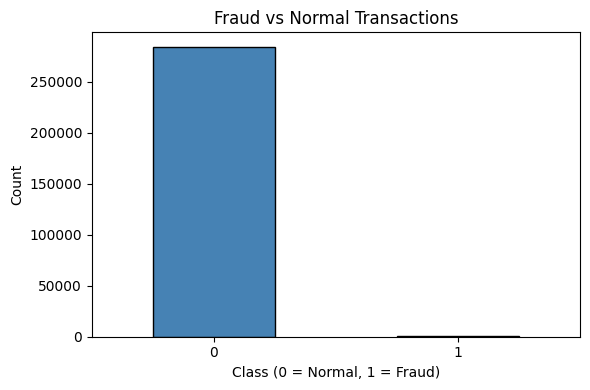

Chart saved!


In [6]:
# Cell 3: Class Distribution
print("Class distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage:", round(df['Class'].mean() * 100, 3), "%")

# Bar chart
plt.figure(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue', 'crimson'], edgecolor='black')
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [7]:
# Cell 4: Data Quality Check
print("Missing values in each column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df[['Time', 'Amount', 'Class']].describe()

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


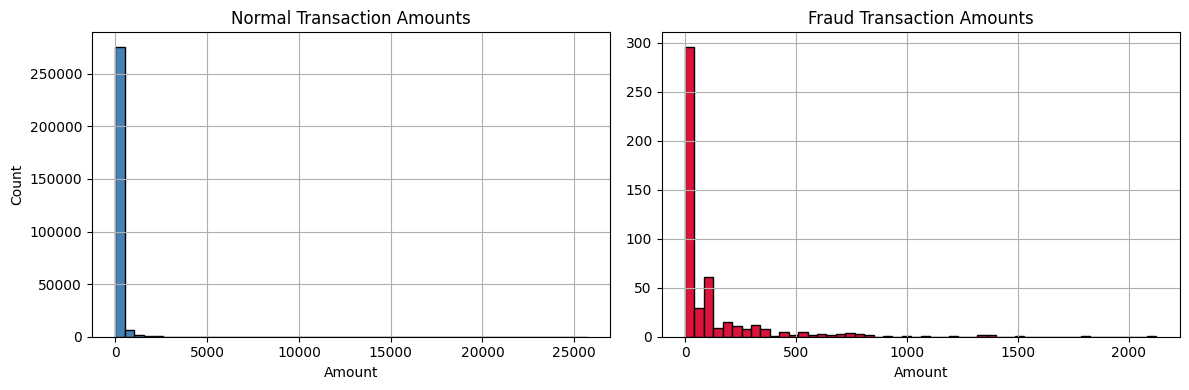

Amount chart saved!


In [8]:
# Cell 5: Amount Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount distribution for normal vs fraud
df[df['Class'] == 0]['Amount'].hist(ax=axes[0], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

df[df['Class'] == 1]['Amount'].hist(ax=axes[1], bins=50, color='crimson', edgecolor='black')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150)
plt.show()
print("Amount chart saved!")

In [9]:
# Cell 6: Prepare Data for ML

# Scale 'Amount' and 'Time' columns (V1-V28 are already scaled by the dataset provider)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time columns
df_clean = df.drop(['Amount', 'Time'], axis=1)

# Split features and target
X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Fraud cases in test set:", y_test.sum())

Training set size: (227845, 30)
Testing set size: (56962, 30)
Fraud cases in test set: 98


In [10]:
# Cell 7: Train the Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

Model trained successfully!

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



<Figure size 600x500 with 0 Axes>

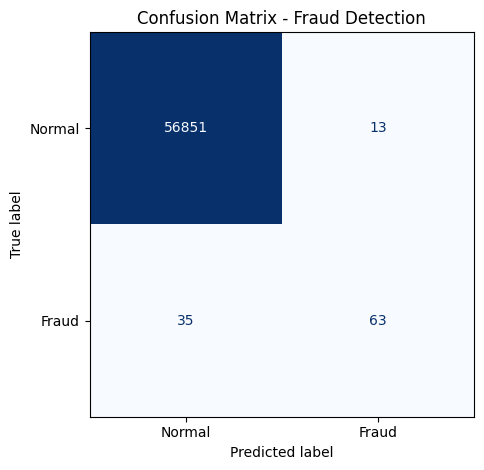

Confusion matrix saved!


In [11]:
# Cell 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Fraud Detection')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

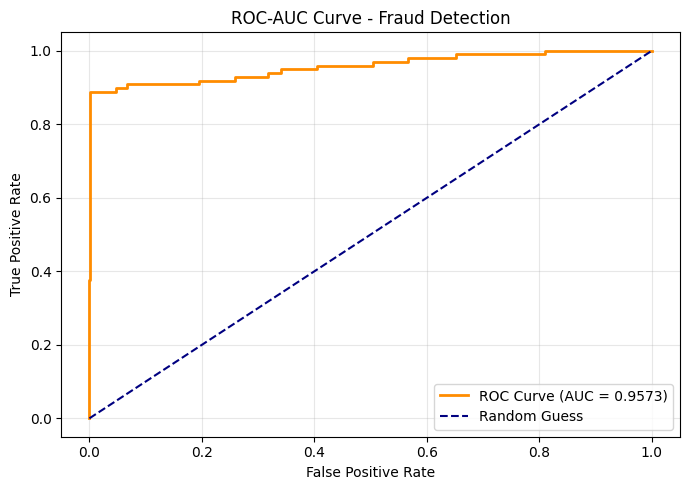


Final ROC-AUC Score: 0.9573
Closer to 1.0 = better model!


In [12]:
# Cell 9: ROC-AUC Curve
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Fraud Detection')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150)
plt.show()

print(f"\nFinal ROC-AUC Score: {roc_auc:.4f}")
print("Closer to 1.0 = better model!")

Insights

1. Model Performance is Strong

An AUC of 0.9573 means the model correctly distinguishes between fraud and legitimate transactions 95.73% of the time. Anything above 0.90 is considered excellent for fraud detection.

2. The Curve Shape Tells a Story

The orange curve shoots up steeply toward the top-left corner immediately — this means the model catches a large percentage of actual fraud cases (high True Positive Rate) while keeping false alarms low. A perfect model would be a right angle hugging the top-left; yours is very close.

3. Far Better Than Random

The dashed navy line = random guessing (AUC = 0.50). Your model at 0.9573 is nearly twice as good as guessing randomly.

4. Class Imbalance Was the Real Challenge

With only 0.17% fraud in the dataset, a lazy model could just predict "normal" every time and still get 99.83% accuracy — but fail completely at catching fraud. The ROC-AUC metric bypasses this trap by measuring performance across all thresholds, making it the right metric here.

5. Logistic Regression Works Surprisingly Well

Even without complex models like Random Forest or Neural Networks, simple Logistic Regression achieves 0.9573 AUC — proving that good feature engineering (scaling Amount and Time) matters more than model complexity at the beginner level.